# Setting Up

## Importing raw data

In [1]:
#This gets us into the right directory from home, in order to run the import python script from Mat

#sys = system (module), gives information and control over python interpreter/terminal itself
import sys
sys.path.append("/home/565/pv3484/aus_substation_electricity")

#% is a magic command, special shortcut command that lets you control/interact with notebook environment (ie. gives control of terminal without writing full python code)
%cd /home/565/pv3484/aus_substation_electricity

!pwd

/home/565/pv3484/aus_substation_electricity
/home/565/pv3484/aus_substation_electricity


In [2]:
#This section imports the substations that Mat put together

%run /home/565/pv3484/aus_substation_electricity/import_substation.py

processing nsw substations for ['ausgrid'] from None to None
ausgrid
following columns in demand are not in info index:
['MT_HU', 'SI_NO']
removing these columns from demand
number of substations in ausgrid substation info: 134
number of substations in ausgrid substation data: 132
following sites match selection criteria:
               energy_asset          Name  Area  Dwellings  Persons  Residential  Commercial  Industrial  Primary Production  Education  \
ID                                                                                                                                        
BLAKE         AG_BLAKEHURST    Blakehurst     7      10081    28521        0.850       0.005       0.021               0.000      0.022   
PUNCH          AG_PUNCHBOWL     Punchbowl     9      17514    50395        0.826       0.048       0.038               0.000      0.025   
MEADO         AG_MEADOWBANK    Meadowbank    15      22420    56948        0.825       0.023       0.015               0

## Lat/lon into info

In [3]:
from geopy.geocoders import Nominatim
import pandas as pd
import time

# Initialize geocoder
geolocator = Nominatim(user_agent="sydney_demand_mapper")

def get_coords(place):
    """Return (lat, lon) for a suburb name, or (None, None) if not found."""
    try:
        loc = geolocator.geocode(f"{place}, New South Wales, Australia")
        if loc:
            return loc.latitude, loc.longitude
    except Exception as e:
        print(f"Geocoding failed for {place}: {e}")
    return None, None

# Apply geocoding to the 'Name' column
latitudes, longitudes = [], []
for suburb in info['Name']:
    lat, lon = get_coords(suburb)
    latitudes.append(lat)
    longitudes.append(lon)
    time.sleep(1)  # polite pause to avoid hitting API limits

info['latitude'] = latitudes
info['longitude'] = longitudes

In [4]:
missing = info[info["latitude"].isna() | info["longitude"].isna()]
missing["Name"].unique()
#Dee Why West doesn't exist as a suburb polygon, so will need to change the name to Dee Why

array(['Dee Why West'], dtype=object)

In [5]:
dee_why_west_lat = -33.73441
dee_why_west_lon = 151.28278
#Found the lat/lon information online

In [6]:
info.loc[info["Name"] == "Dee Why West", "latitude"] = dee_why_west_lat
info.loc[info["Name"] == "Dee Why West", "longitude"] = dee_why_west_lon
#inputting lat and lon from online into info

## Holiday Function

In [7]:
import pandas as pd
from datetime import date, timedelta
from dateutil.easter import easter

#Monarch's Birthday
def second_monday_of_june(y):
    """Return the date of the second Monday in June for year y."""
    june = pd.date_range(start=f"{y}-06-01", end=f"{y}-06-30", freq="D")
    mondays = june[june.weekday == 0]   # Monday = 0
    return mondays[1]                   # second Monday



# Define all national public holidays (including moving ones like Easter)
HOLIDAYS_VIC = {
    "New Year's Day": lambda y: pd.Timestamp(f"{y}-01-01"),
    "Australia Day": lambda y: pd.Timestamp(f"{y}-01-26"),
    "Good Friday": lambda y: pd.Timestamp(easter(y)) - pd.Timedelta(days=2),
    "Easter Saturday": lambda y: pd.Timestamp(easter(y)) - pd.Timedelta(days=1),
    "Easter Sunday": lambda y: pd.Timestamp(easter(y)),
    "Easter Monday": lambda y: pd.Timestamp(easter(y)) + pd.Timedelta(days=1),
    "ANZAC Day": lambda y: pd.Timestamp(f"{y}-04-25"),
    "Monarch's Birthday": lambda y: second_monday_of_june(y),
    "Christmas Day": lambda y: pd.Timestamp(f"{y}-12-25"),
    "Boxing Day": lambda y: pd.Timestamp(f"{y}-12-26"),
}

holiday_order = list(HOLIDAYS_VIC.keys())

## Import CSV

In [8]:
import pandas as pd

rank = pd.read_csv(
    "/home/565/pv3484/aus_substation_electricity/data/cleaned_data/full_nsw_relative_rank.csv"
)


## Time blocks

In [9]:
blocks = {
    "00_04": range(0, 4),
    "04_10": range(4, 10),
    "10_15": range(10, 15),
    "15_20": range(15, 20),
    "20_24": range(20, 24)
}


## Temperature for plotting

In [10]:
# Ensure datetime index
obs.index = pd.to_datetime(obs.index)

# Extract hour + date
obs["hour"] = obs.index.hour
obs["date"] = obs.index.date

# Prepare output list
temp_rows = []

# Loop over each day
for day, df_day in obs.groupby("date"):

    row = {"date": pd.Timestamp(day)}

    # Loop over each block
    for block_name, hours in blocks.items():
        block_vals = df_day[df_day["hour"].isin(hours)]["t2m"]

        # Mean temperature for this block
        row[f"{block_name}_temp_mean"] = block_vals.mean()

    temp_rows.append(row)

# Convert to DataFrame
temp_blocks = pd.DataFrame(temp_rows)


In [11]:
# Ensure datetime
rank["date"] = pd.to_datetime(rank["date"])
temp_blocks["date"] = pd.to_datetime(temp_blocks["date"])

# Merge block-level temperatures into rank
rank = rank.merge(
    temp_blocks,
    on="date",
    how="left"
)


# 1x3 panel map (for each time block)
- public holiday, weekday and weekend
- ranking of the day minus weekend/day
- Difference in ranking for each time block
- mapped with substations above residential fraction of 75%

In [91]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

def map_ph_we_wd_block(
    df,
    info,
    holiday,
    block,
    df_station_col="station_name",
    info_station_col="Name",
    lat_col="latitude",
    lon_col="longitude",
    residential_col="Residential",
    residential_threshold=0.75,
    block_suffix="_mean",
    crs_epsg=3857
):
    """
    Creates a 1×3 spatial map for a single time block:
        1. Mean Relative Rank
        2. Mean Relative Rank − Weekend Mean Relative Rank
        3. Mean Relative Rank − Weekday Mean Relative Rank
    """

    # 1. Filter to high-residential stations
    high_res = info[info[residential_col] >= residential_threshold].copy()
    high_res_names = high_res[info_station_col].unique()
    df = df[df[df_station_col].isin(high_res_names)].copy()

    # 2. Filter to selected holiday
    df_hol = df[df["holiday"] == holiday].copy()

    # 3. Prepare GeoDataFrame
    gdf = high_res.copy()
    gdf = gpd.GeoDataFrame(
        gdf,
        geometry=gpd.points_from_xy(gdf[lon_col], gdf[lat_col]),
        crs="EPSG:4326"
    ).to_crs(crs_epsg)

    # 4. Compute PH, PH-WE, PH-WD
    results = []
    col = f"{block}{block_suffix}"

    for station in gdf[info_station_col]:
        df_s = df_hol[df_hol[df_station_col] == station]
        if df_s.empty:
            continue

        df_ph = df_s[df_s["is_holiday"] == True]
        ph_vals = df_ph.groupby("year")[col].mean().rename("ph")

        df_we = df_s[(df_s["is_holiday"] == False) & (df_s["is_weekend"] == True)]
        we_vals = df_we.groupby("year")[col].mean().rename("we")

        df_wd = df_s[(df_s["is_holiday"] == False) & (df_s["is_weekend"] == False)]
        wd_vals = df_wd.groupby("year")[col].mean().rename("wd")

        merged = (
            ph_vals.to_frame()
            .merge(we_vals, on="year", how="left")
            .merge(wd_vals, on="year", how="left")
        )

        merged["ph_we"] = merged["ph"] - merged["we"]
        merged["ph_wd"] = merged["ph"] - merged["wd"]

        vals = merged.mean()

        results.append({
            info_station_col: station,
            "ph": vals["ph"],
            "ph_we": vals["ph_we"],
            "ph_wd": vals["ph_wd"]
        })

    # 5. Merge results back into GeoDataFrame
    res_df = pd.DataFrame(results)
    gdf = gdf.merge(res_df, on=info_station_col, how="left")

    # 6. Compute padded extent for zoom-out
    minx, miny, maxx, maxy = gdf.total_bounds
    pad = 4800  # metres
    extent = (minx - pad, maxx + pad, miny - pad, maxy + pad)

    # 7. Plotting
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

    # Overarching title using actual holiday name
    year_min = int(df_hol["year"].min())
    year_max = int(df_hol["year"].max())
    block_label = block.replace("_", ":").replace("15:20", "15:00–20:00")
    fig.suptitle(
        f"Relative Demand Patterns on {holiday} ({block_label}, 2-year rolling window ({year_min}–{year_max})\n"
        f"High‑residential locations only (≥ 0.75)",
        fontsize=16,
        y=1.02
    )



    panels = [
        ("Mean Relative Rank", "ph"),
        ("Mean Relative Rank − Weekend Mean Relative Rank", "ph_we"),
        ("Mean Relative Rank − Weekday Mean Relative Rank", "ph_wd")
    ]

    for ax, (title, colname) in zip(axes, panels):

        gdf.plot(
            ax=ax,
            column=colname,
            cmap="coolwarm",
            legend=True,
            markersize=60,
            edgecolor="black",
            legend_kwds={
                "label": (
                    "Red = higher Public Holiday rank (higher relative demand)\n"
                    "Blue = lower Public Holiday rank"
                    if colname == "ph"
                    else "Red = Public Holiday > baseline, Blue = Public Holiday < baseline"
                )
            }
        )

        ax.set_xlim(extent[0], extent[1])
        ax.set_ylim(extent[2], extent[3])

        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

        for _, row in gdf.iterrows():
            ax.text(
                row.geometry.x + 800,
                row.geometry.y + 0,
                row[info_station_col],
                fontsize=7,
                ha="left",
                va="center"
            )

        ax.set_title(title)
        ax.set_axis_off()

    plt.tight_layout()
    plt.show()


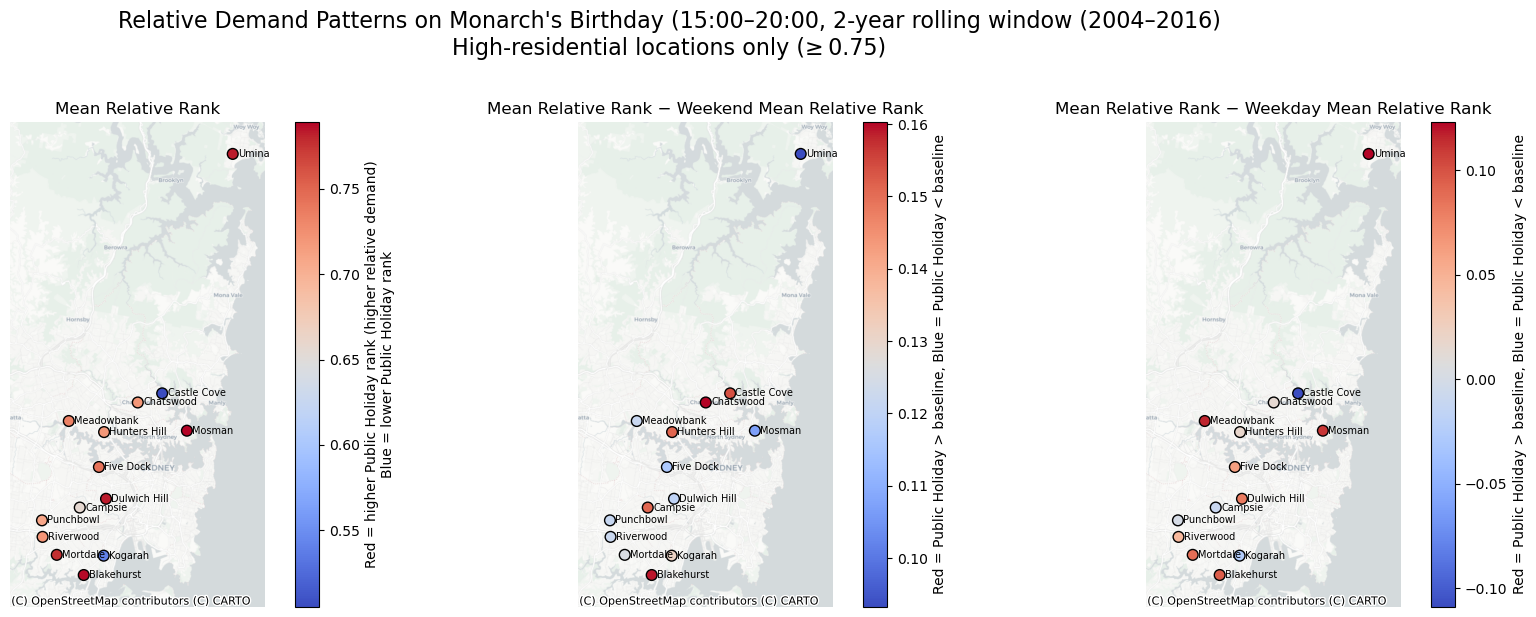

In [92]:
map_ph_we_wd_block(
    df=rank,
    info=info,
    holiday="Monarch's Birthday",
    block="15_20"
)


In [ ]:
print(rank["station_code"].unique()[:20])
print(info["energy_asset"].unique()[:20])


In [ ]:
print(rank["station_name"].unique()[:20])
print(info["Name"].unique()[:20])


## Producing a table of the mapped results

In [79]:
def make_ph_we_wd_table(
    df,
    info,
    holiday,
    block,
    df_station_col="station_name",
    info_station_col="Name",
    residential_col="Residential",
    residential_threshold=0.75,
    block_suffix="_mean"
):
    """
    Returns a table of:
        - <holiday> Mean Relative Rank
        - <holiday> − Weekend Mean Relative Rank
        - <holiday> − Weekday Mean Relative Rank
        - Residential Fraction
    """

    # Filter to high-residential stations
    high_res = info[info[residential_col] >= residential_threshold].copy()
    high_res_names = high_res[info_station_col].unique()
    df = df[df[df_station_col].isin(high_res_names)].copy()

    # Filter to selected holiday
    df_hol = df[df["holiday"] == holiday].copy()

    results = []
    col = f"{block}{block_suffix}"

    for station in high_res_names:
        df_s = df_hol[df_hol[df_station_col] == station]
        if df_s.empty:
            continue

        # PH
        df_ph = df_s[df_s["is_holiday"] == True]
        ph_vals = df_ph.groupby("year")[col].mean().rename("ph")

        # Weekend baseline
        df_we = df_s[(df_s["is_holiday"] == False) & (df_s["is_weekend"] == True)]
        we_vals = df_we.groupby("year")[col].mean().rename("we")

        # Weekday baseline
        df_wd = df_s[(df_s["is_holiday"] == False) & (df_s["is_weekend"] == False)]
        wd_vals = df_wd.groupby("year")[col].mean().rename("wd")

        merged = (
            ph_vals.to_frame()
            .merge(we_vals, on="year", how="left")
            .merge(wd_vals, on="year", how="left")
        )

        merged["ph_we"] = merged["ph"] - merged["we"]
        merged["ph_wd"] = merged["ph"] - merged["wd"]

        vals = merged.mean()

        results.append({
            info_station_col: station,
            "ph": vals["ph"],
            "ph_we": vals["ph_we"],
            "ph_wd": vals["ph_wd"]
        })

    table = pd.DataFrame(results)

    # Merge residential fraction from info
    table = table.merge(
        info[[info_station_col, residential_col]],
        on=info_station_col,
        how="left"
    )

    # Rename columns using the actual holiday name
    table = table.rename(columns={
        "ph": f"{holiday} Mean Relative Rank",
        "ph_we": f"{holiday} − Weekend Mean Relative Rank",
        "ph_wd": f"{holiday} − Weekday Mean Relative Rank",
        residential_col: "Residential Fraction"
    })

    # Sort for readability
    table = table.sort_values(f"{holiday} Mean Relative Rank", ascending=False).reset_index(drop=True)

    return table


In [80]:
table = make_ph_we_wd_table(rank, info, "Monarch's Birthday", "15_20")
table


,Name,Monarch's Birthday Mean Relative Rank,Monarch's Birthday − Weekend Mean Relative Rank,Monarch's Birthday − Weekday Mean Relative Rank,Residential Fraction
0,Mosman,0.788946,0.107092,0.111263,0.817
1,Blakehurst,0.787454,0.159136,0.095771,0.850
2,Umina,0.783369,0.093241,0.123205,0.790
3,Dulwich Hill,0.782338,0.119884,0.080914,0.799
4,Mortdale,0.776577,0.125513,0.087335,0.778
5,Five Dock,0.743123,0.116240,0.061905,0.798
6,Meadowbank,0.734246,0.121982,0.116136,0.825
7,Riverwood,0.721146,0.122135,0.045276,0.813
8,Chatswood,0.719908,0.160306,0.014956,0.766
9,Hunters Hill,0.719185,0.151381,0.017483,0.782
